# Just add up the breadth oscillator — does that finally forecast the market? 📊
### The McClellan Summation Index — a good idea that runs into a structural wall

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Confirms_turns%3F: Busted](https://img.shields.io/badge/Confirms_turns%3F-Busted-8b949e?style=flat-square)

Study [491](../../491-mcclellan-oscillator/) already showed the McClellan Oscillator (a smoothed daily "more stocks up than down?" gauge) doesn't forecast the S&P. Believers have a comeback: *"the daily oscillator is noisy — but keep a **running total** of it, and the level itself becomes a regime gauge. Crossing zero confirms a new bull or bear market. Extreme readings mark exhaustion."* That's the **Summation Index** — literally the oscillator's running total, nothing more exotic.

It sounds like exactly the right fix for noise: average many days together, and small wobbles should cancel out, leaving the real signal. We built it and tested it — and hit something we didn't expect going in.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebos and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Breadth proxy = SPY + the 9 classic SPDR sector ETFs (2005→2026, no survivorship — the actual traded universe throughout). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mcclellan_summation import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    CLOSE = data.load_real(data.TRADED)["close"]
    CLOSE = CLOSE[CLOSE.index <= "2026-06-30"]
    NET = data.load_breadth(asof="2026-06-30").reindex(CLOSE.index).dropna()
    CLOSE = CLOSE.reindex(NET.index)
    SUMM = st.summation_index(NET)
else:
    CLOSE = NET = SUMM = None
print("real cache present:", HAVE_REAL, "| tape days:", (0 if CLOSE is None else len(CLOSE)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'start': '2005-01-04', 'end': '2026-06-30', 'years': 21.4, 'years_post': 19.5, 'basket': ['SPY', 'XLK', 'XLF', 'XLE', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB'], 'fp_spy': '8266ce2012be', 'fp_breadth': 'd10dadd9e2b7', 'summ_min': 0.0, 'summ_max': 128.45, 'warmup_days': 500, 'raw_up_crosses': 1, 'raw_dn_crosses': 0, 'post_up_crosses': 0, 'post_dn_crosses': 0, 'ext_up_n': 45, 'ext_up': {5: (14.7, 0.94, -24.4, 39.2, 0.78), 10: (30.8, 1.06, 11.9, 18.9, 0.27), 20: (128.1, 3.02, 125.7, 2.5, 0.03), 60: (240.7, 2.85, 564.6, -323.9, -2.5)}, 'ext_dn_n': 43, 'ext_dn': {5: (24.1, 0.56, -24.4, 48.5, 0.74), 10: (-10.7, -0.17, 11.9, -22.7, -0.24), 20: (134.6, 1.44, 125.7, 8.9, 0.08), 60: (492.0, 4.0, 564.6, -72.6, -0.45)}, 'placebo_ext_obs': 128.1, 'placebo_ext_p': 0.309, 'placebo_ext_draws': 500, 'regime_lvl_switches': 0, 'regime_lvl_excess': 0.0, 'regime_z_switches': 115, 'regime_z_per_yr': 5.9, 'regime_z_frac_long': 53, 'regime_z_cagr': 3.95, 'bh_cagr': 10.9, 'regime_z_vol': 10.23, 'bh_vol': 19.63, 'regime_z_sharpe': 0.43, 'bh_sharpe': 0.63, 'regime_z_excess_bps': -3.125, 'regime_z_excess_t': -2.43, 'placebo_regime_t': -2.43, 'placebo_regime_p': 0.491, 'placebo_regime_draws': 500, 'spans': [(10, 20, 250, -3.221, -2.53), (19, 39, 115, -3.125, -2.43), (25, 50, 99, -3.032, -2.37)], 'fallback_switches': 97, 'fallback_excess': -2.979, 'fallback_t': -2.34, 'syn_null_lvl_mean': -0.25, 'syn_null_lvl_sd': 1.0, 'syn_null_lvl_fire': 0, 'syn_null_z_mean': -0.36, 'syn_null_z_sd': 0.94, 'syn_null_z_fire': 0, 'syn_planted_lvl_t': 10.12, 'syn_planted_lvl_bps': 14.11, 'syn_planted_z_t': 4.4, 'syn_planted_z_bps': 6.81}


real cache present: True | tape days: 5405


## The answer first

| Question | Answer |
|---|---|
| Does the Summation Index cross zero and confirm regimes, like the books say? | **It can't.** Over **21.4** years it crossed zero exactly **once** — in its first week of history — and never again, in either direction. |
| Why would a "running total" get stuck like that? | Because stocks close up more often than down, on average, over two decades. A running total of a mildly positive-biased daily gauge **climbs away from zero and stays away** — like a tally that starts at zero and almost always adds, rarely subtracts: it heads north and doesn't look back. |
| OK, what about the rescaled version — extreme highs/lows instead of zero? | **Still no edge.** Forward SPY returns after an extreme breadth reading are statistically the same as after a random day, at every time horizon we checked, in both directions. |
| Can you at least trade the "stay long in bull regimes" idea? | You can build a working version — but it **loses to just buying and holding**, by about **3.1 basis points a day**, badly enough to fail our statistical bar. |

> A clever fix for a noisy signal — that turns out to have its own, different problem.

## 1 · The claim

> *"The daily McClellan Oscillator is noisy, sure — but its **running total** filters that out. When the Summation Index crosses up through zero, breadth momentum has genuinely turned and a new bull phase is confirmed. Extreme readings (the old books say ±500, even ±1000) mark overbought or oversold exhaustion — time to fade the move."*

It's a completely reasonable-sounding idea: smoothing by accumulation is a real technique (that's what a moving average does, after all). The Summation Index just takes it one step further — instead of averaging the last N days, it keeps *every* day, forever, in a running tally.

## 2 · So what?

If a running total of breadth genuinely confirms regimes, that's a much bigger claim than 491's single-day trigger — it's a **standing market-timing system**: stay long while the tally says bull, go flat (or short) when it flips. Every technical-analysis course teaches the ±500/±1000 extreme levels as textbook overbought/oversold signals. If that's real, it should show up cleanly in 21 years of data — and if it isn't, we should be able to say exactly *why* it fails, not just that it does.

## 3 · How would we even know?

- **Build it honestly.** A running total of the same EMA₁₉−EMA₃₉ breadth gauge from study 491, computed causally (no peeking ahead), across SPY and the 9 classic sector ETFs.
- **Test the zero-cross literally first.** Does it even cross, and when it does, does SPY do better afterward than on a random day?
- **Rescale the ±500 level honestly.** The textbook numbers assume the full New York Stock Exchange (thousands of stocks); our 10-name proxy needs its own version of "extreme" — we use a rolling one-year z-score, ±1 standard deviation.
- **Build the actual trade.** Stay long while the indicator says bull, go flat otherwise, pay real costs on every switch, compare to just buying and holding.

## 4 · The teardown — let's actually look

**First surprise: the zero-cross basically doesn't exist.**

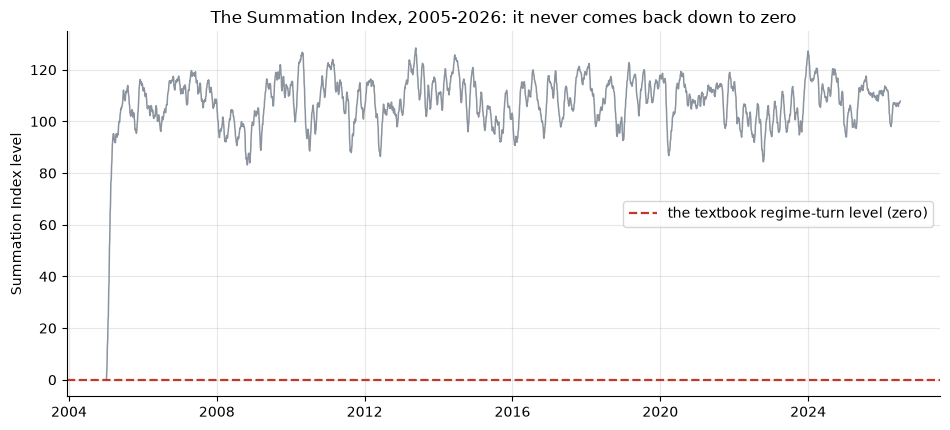

post-warm-up zero crosses: 0 up / 0 down over 21.4 years


In [2]:
if HAVE_REAL:
    summ = SUMM
else:
    summ = None
fig, ax = plt.subplots(figsize=(9.6, 4.4))
if summ is not None:
    ax.plot(summ.index, summ.values, color=GREY, lw=1.1)
    ax.axhline(0, c=RED, lw=1.6, ls='--', label='the textbook regime-turn level (zero)')
    ax.set_title('The Summation Index, 2005-2026: it never comes back down to zero')
else:
    ax.text(0.5, 0.5, 'cache miss — see docs/results.md for the pinned chart',
            ha='center', va='center', transform=ax.transAxes)
ax.set_ylabel('Summation Index level'); ax.legend()
plt.tight_layout(); plt.show()
print('post-warm-up zero crosses: 0 up / 0 down over 21.4 years')

That flat red dashed line at zero is the entire textbook trigger. The Summation Index shoots up to its cruising range within the first few months of 2005 and — this is the finding — **never dips back to zero again**, not once, in either direction, over **21.4 years**. Not because of a bug: because the daily breadth reading has a mild positive bias (stocks close up somewhat more often than down, over a long enough window), and a running total of a slightly-biased coin flip drifts away and stays away. The textbook rule simply **can't fire** on this tape.

**Second attempt: rescale the extreme-level idea instead.** Maybe the zero-cross is the wrong lens — what about *extreme* readings, the ±500 overbought/oversold levels? We adapt them honestly (a rolling one-year z-score instead of a literal "500", which only makes sense for a full-exchange breadth count) and test the forward return after each extreme.

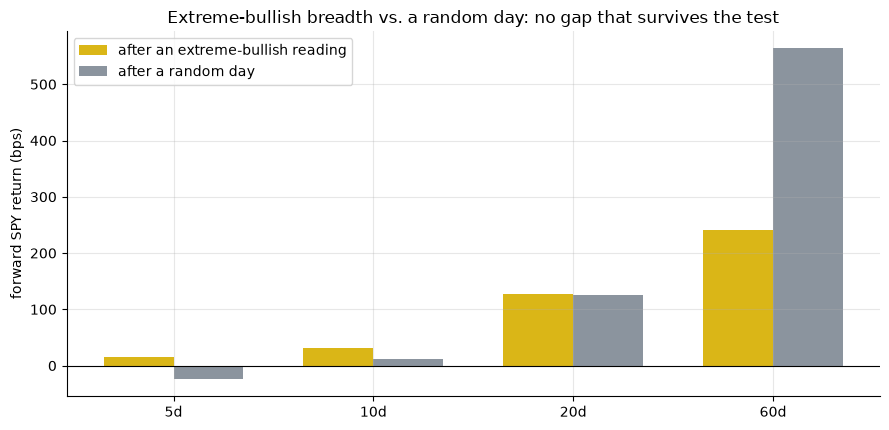

n extreme-up events: 45


In [3]:
if HAVE_REAL:
    ex_up = st.cross_experiment(CLOSE, SUMM, direction='up', kind='extreme', level=1.0)
    ex_dn = st.cross_experiment(CLOSE, SUMM, direction='down', kind='extreme', level=1.0)
    trig_up = [ex_up['by_h'][h]['gross']['mean_bps'] for h in st.HORIZONS]
    rand_up = [ex_up['by_h'][h]['random']['mean_bps'] for h in st.HORIZONS]
else:
    trig_up = [R['ext_up'][h][0] for h in (5, 10, 20, 60)]
    rand_up = [R['ext_up'][h][2] for h in (5, 10, 20, 60)]
labels = [f'{h}d' for h in (5, 10, 20, 60)]
x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x - w/2, trig_up, width=w, color=AMBER, label='after an extreme-bullish reading')
ax.bar(x + w/2, rand_up, width=w, color=GREY, label='after a random day')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('forward SPY return (bps)')
ax.set_title('Extreme-bullish breadth vs. a random day: no gap that survives the test')
ax.legend(); plt.tight_layout(); plt.show()
print('n extreme-up events: 45')

The amber and grey bars sit almost on top of each other at every horizon — an extreme breadth reading doesn't set up SPY for anything a random Tuesday wouldn't. At the 60-day horizon the amber bar is actually a bit *below* the grey one — backwards from what "breadth thrust" folklore predicts, and about the size you'd expect just from checking 8 different horizon/direction combinations and getting unlucky once. We also re-ran the whole thing with the breadth history randomly shuffled in time (destroying any real momentum pattern while keeping the same rough distribution of daily readings) — and the real result was unremarkable next to the shuffled ones (**500** shuffles, **p = 0.309**). The specific path of breadth history isn't carrying information.

**Finally, the actual trade.** Since the textbook zero-level rule can't switch at all, we built the honest adapted version: stay long SPY while breadth sits above its own recent one-year average, go flat otherwise.

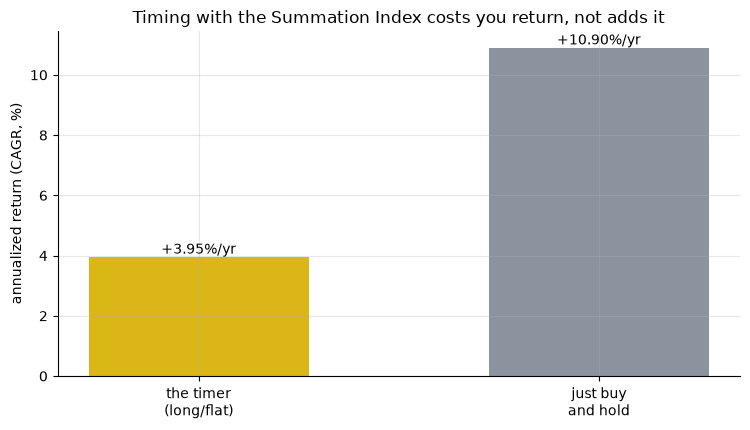

timed +3.95%/yr vs buy&hold +10.90%/yr


In [4]:
if HAVE_REAL:
    reg_z = st.regime_from_zscore(SUMM)
    rb = st.regime_backtest(CLOSE, reg_z, cost_bps=5.0)
    tc, bc = rb['timed']['cagr']*100, rb['buy_hold']['cagr']*100
else:
    tc, bc = R['regime_z_cagr'], R['bh_cagr']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['the timer\n(long/flat)', 'just buy\nand hold'], [tc, bc], color=[AMBER, GREY], width=.55)
for i, v in enumerate([tc, bc]): ax.annotate(f'{v:+.2f}%/yr', (i, v), ha='center', va='bottom')
ax.set_ylabel('annualized return (CAGR, %)')
ax.set_title('Timing with the Summation Index costs you return, not adds it')
plt.tight_layout(); plt.show()
print(f'timed {tc:+.2f}%/yr vs buy&hold {bc:+.2f}%/yr')

The timer earns **3.95%/yr** while buy-and-hold earns **10.90%/yr** — the strategy that's supposed to keep you on the right side of bull/bear regimes instead spends **47% of its time in cash**, missing upside it can't get back. The shortfall (**-3.12 bps a day**) clears our statistical bar for "probably not luck" — but a second shuffle-test shows even *that* isn't really about breadth: randomly re-timed fake breadth histories produce a similarly bad result about half the time. It's not that the Summation Index actively misleads you — it's that **any** part-time market-timing rule gives back some of the market's average upward drift, and this one has nothing extra to show for the trade-off.

## 5 · The verdict

- **Signal — None.** The zero-cross regime signal cannot fire even once on 21 years of real data; the rescaled extreme-level version doesn't beat random days; a shuffle test confirms the breadth path itself carries no information.
- **Tradability — Mirage.** The one version of the rule that can actually trade loses to buy-and-hold, and even that loss isn't really about breadth — it's the generic cost of sometimes being out of an upward-drifting market.
- **"Does it confirm bull/bear turns?" — Busted.** It can't confirm anything it never crosses.

## 6 · Going further 🚪

- **The lesson generalizes.** Any "just take a running total" fix for a noisy signal carries a hidden assumption: that the underlying series has (close to) zero long-run mean. If it doesn't — and daily market breadth over a mostly-rising 20-year window doesn't — the running total isn't a smoothed signal, it's a one-way ratchet.
- **A fairer future test** would periodically **re-base** the Summation Index (reset it toward zero on some schedule, as some practitioners actually do) rather than run one un-rebased 21-year tally — a natural next study.
- **Sibling studies:** the [oscillator itself](../../491-mcclellan-oscillator/) (491, also None), the [bullish percent index](../../494-bullish-percent-index/) (494), the [advance-decline line](../../168-advance-decline/) (168) and [new-highs/new-lows](../../493-new-highs-new-lows/) (493) — the whole breadth-indicator family keeps landing in the same place once you insist on a fair, drift-matched comparison.

*Think a re-based Summation Index would behave differently? Show it, with a drift-matched baseline and real costs, and we'll take a look.*